**En su conjunto, este cuaderno recibe los datos brutos del proceso de extracción, limpia la base de datos de ruido y errores de medición, y cruza los registros meteorológicos históricos que nos proporcionó la AEMET con la reflectancia de los satélites Copernicus para generar la verdad fundamental (Ground Truth), dejando el dataset limpio y listo para que la red neuronal convolucional comience su entrenamiento.**

1. IMPORTACIONES DE LIBRERIAS Y PARAMETROS DEL ENTORNO.

Configuro las librerías analíticas necesarias como Pandas, NumPy y Scikit-learn, silencio las advertencias matemáticas irrelevantes para mantener la consola limpia y defino las rutas del sistema de archivos. Dejo preparado un bloque comentado con el comando gdown para que el tribunal pueda saltarse el proceso ETL y volcar el dataset comprimido (el generado en el cuaderno 1) directamente en la memoria temporal de su sesión de Colab.

In [1]:
# Importaciones estándar y de terceros
import os
import shutil
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler

# Silencio las advertencias
warnings.filterwarnings('ignore', r'Mean of empty slice')

# --- INGESTA DIRECTA ---
# ID del archivo ZIP alojado en Google Drive
ID_DRIVE = "1XBvBSGBhvIAs4gvicLpdjWRVSc4GeDlQ"

!gdown --id {ID_DRIVE} -O dataset_tfm.zip
!unzip -q dataset_tfm.zip -d /content/dataset_tfm/

# --- CONFIGURACIÓN DE RUTAS LOCALES ---
RUTA_BASE = '/content/dataset_tfm'

RUTA_DATASET_CSV = os.path.join(RUTA_BASE, 'dataset_meteo_satelite.csv')
RUTA_TENSORES = os.path.join(RUTA_BASE, 'tensores_satelite')
RUTA_ESCALADOR = os.path.join(RUTA_BASE, 'robust_scaler_meteo.pkl')
RUTA_DATASET_FINAL = os.path.join(RUTA_BASE, 'dataset_final_tfm.csv')

VARIABLES_METEO = ['tmax', 'hrMedia', 'velmedia']

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1XBvBSGBhvIAs4gvicLpdjWRVSc4GeDlQ
From (redirected): https://drive.google.com/uc?id=1XBvBSGBhvIAs4gvicLpdjWRVSc4GeDlQ&confirm=t&uuid=945b6adc-9199-450b-bd50-b9d7ab0df50d
To: /content/dataset_tfm.zip
100% 749M/749M [00:09<00:00, 78.1MB/s]
replace /content/dataset_tfm/dataset_meteo_satelite.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


2. MODULO DE DEPURACION E IMPUTACION.

Reviso el dataset para descartar cualquier observación cuyo tensor satelital .npy haya fallado en la descarga. A continuación, barro el dataset en busca de fallos de los sensores (temperaturas, humedades y vientos anómalos y/o imposibles) y los convierto en nulos. Para no perder esas filas, aplico el algoritmo KNNImputer agrupando por estación, de manera que la IA deduce el valor real basándose en los 5 días climatológicamente más similares de ese mismo microclima.

In [2]:
def cargar_y_verificar_dataset(ruta_csv: str, ruta_tensores: str) -> pd.DataFrame:
    """
    Carga el dataset tabular y descarta aquellas observaciones cuyo parche
    satelital no se haya podido descargar o esté corrupto en el disco.

    Parameters
    ----------
    ruta_csv : str
        Ruta al archivo CSV maestro.
    ruta_tensores : str
        Ruta al directorio que contiene las matrices en formato .npy.

    Returns
    -------
    pd.DataFrame
        Dataset sincronizado donde cada fila tiene su imagen garantizada.
    """
    df = pd.read_csv(ruta_csv)
    df['nombre_tensor'] = df['indicativo'] + '_' + df['fecha'] + '.npy'

    # Compruebo la existencia física del tensor en el directorio
    df['tensor_existe'] = df['nombre_tensor'].apply(lambda x: os.path.exists(os.path.join(ruta_tensores, x)))
    df_sincronizado = df[df['tensor_existe']].copy()
    df_sincronizado.drop(columns=['tensor_existe'], inplace=True)

    return df_sincronizado

def aplicar_limites_fisicos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta y neutraliza (convirtiendo a NaN) los registros meteorológicos que
    son anomalías climatológicas y físicas para Canarias. Esto es, temperaturas inferiores a
    -25ºC y superiores a 60, humedades relativas negativas o superiores a 100% y
    valocidades negativas o mayores a 250km/h.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset meteorológico a evaluar.

    Returns
    -------
    pd.DataFrame
        Dataset con las anomalías reemplazadas por valores nulos (NaN).
    """
    df_limpio = df.copy()

    mascara_tmax = (df_limpio['tmax'] < -25) | (df_limpio['tmax'] > 60)
    mascara_hr = (df_limpio['hrMedia'] < 0) | (df_limpio['hrMedia'] > 100)
    mascara_viento = (df_limpio['velmedia'] < 0) | (df_limpio['velmedia'] > 250)

    df_limpio.loc[mascara_tmax, 'tmax'] = np.nan
    df_limpio.loc[mascara_hr, 'hrMedia'] = np.nan
    df_limpio.loc[mascara_viento, 'velmedia'] = np.nan

    fallos_totales = mascara_tmax.sum() + mascara_hr.sum() + mascara_viento.sum()
    print(f"anomalías absolutas detectadas y anuladas: {fallos_totales}")

    return df_limpio

def imputar_nulos_espaciotemporales(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rellena los valores nulos (NaN) basándose en los 5 días climatológicamente
    más similares (KNN) dentro del histórico de su misma estación.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con valores nulos a imputar.

    Returns
    -------
    pd.DataFrame
        Dataset completamente reconstruido y sin valores faltantes.
    """
    df_imputado = df.copy()
    df_imputado['mes'] = pd.to_datetime(df_imputado['fecha']).dt.month
    columnas_knn = VARIABLES_METEO + ['mes']

    # Utilizo distancia euclidiana ponderada para dar más peso a los días más idénticos
    knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
    estaciones = df_imputado['indicativo'].unique()

    # Aíslo el contexto por estación para evitar mezclar microclimas (ej. cumbre vs costa)
    for estacion in estaciones:
        mascara_estacion = df_imputado['indicativo'] == estacion
        df_estacion = df_imputado.loc[mascara_estacion, columnas_knn]

        if df_estacion[VARIABLES_METEO].isna().sum().sum() > 0:
            matriz_imputada = knn_imputer.fit_transform(df_estacion)
            df_imputado.loc[mascara_estacion, VARIABLES_METEO] = matriz_imputada[:, :3]

    df_imputado.drop(columns=['mes'], inplace=True)
    return df_imputado

# EJECUCIÓN DEL FLUJO DE LIMPIEZA
print("sincronizando datos tabulares con imágenes espaciales...")
df_sincronizado = cargar_y_verificar_dataset(RUTA_DATASET_CSV, RUTA_TENSORES)
print(f"muestras retenidas tras purgar imágenes fallidas: {len(df_sincronizado)}")

print("\naplicando filtro de límites físicos...")
df_sincronizado = aplicar_limites_fisicos(df_sincronizado)

print("imputando valores faltantes mediante K-Nearest Neighbors...")
df_sincronizado = imputar_nulos_espaciotemporales(df_sincronizado)

sincronizando datos tabulares con imágenes espaciales...
muestras retenidas tras purgar imágenes fallidas: 18476

aplicando filtro de límites físicos...
anomalías absolutas detectadas y anuladas: 0
imputando valores faltantes mediante K-Nearest Neighbors...


3. CÁLCULO DEL GROUND TRUTH

Construyo la variable objetivo (Riesgo_Total). Calculo el índice de peligrosidad atmosférica combinando los umbrales de temperatura, humedad y viento. En paralelo, abro uno a uno los 20.000 tensores satelitales y les aplico un triple escáner espectral: aíslo la tierra de los cuerpos de agua (mar, embalses, etc) (NDWI), filtro las zonas urbanas y la roca para quedarme solo con la biomasa forestal (NDVI) y, finalmente, mido la sequedad interna de esa vegetación (NDMI). Pondero tácticamente la disponibilidad de combustible (65%) frente a la meteo puntual (35%). Ya que hay menos riesgo un dia de calor y baja humedad pero con la vegetación saludable (bajo estres hidrico esencialmente), que un día de clima moderado pero con gran sequía de semanas/meses previos y la vegetación poco hidratada.

In [3]:
def calcular_riesgo_meteorologico(df: pd.DataFrame) -> pd.Series:
    """
    Calcula el riesgo de incendio derivado exclusivamente de las condiciones atmosféricas.
    Aplica umbrales operativos para temperatura, humedad y viento, normalizándolos de 0 a 1.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con las variables meteorológicas limpias ('tmax', 'hrMedia', 'velmedia').

    Returns
    -------
    pd.Series
        Serie numérica con el promedio ponderado del riesgo meteorológico (de 0.0 a 1.0).
    """
    r_temp = np.clip((df['tmax'] - 15) / 25, 0, 1)
    r_humedad = np.clip((80 - df['hrMedia']) / 60, 0, 1)
    r_viento = np.clip(df['velmedia'] / 50, 0, 1)

    return (r_temp + r_humedad + r_viento) / 3

def calcular_riesgo_combustible(df: pd.DataFrame, ruta_tensores: str) -> list:
    """
    Calcula el estrés hídrico de la vegetación (NDMI) aplicando un triple filtro
    espectral para descartar masas de agua (NDWI) y zonas urbanas/rocosas (NDVI).

    Parameters
    ----------
    df : pd.DataFrame
        Dataset que contiene los nombres de los archivos de los tensores satelitales.
    ruta_tensores : str
        Directorio físico donde se almacenan las matrices .npy.

    Returns
    -------
    list
        Lista de valores flotantes (0.0 a 1.0) correspondientes al riesgo medio de
        la biomasa forestal válida en cada parche. Si no hay vegetación, devuelve 0.0.
    """
    riesgos_veg = []

    for archivo in tqdm(df['nombre_tensor'], desc="procesando espectrometría"):
        tensor = np.load(os.path.join(ruta_tensores, archivo))

        b3_green = tensor[:, :, 1]
        b4_red   = tensor[:, :, 2]
        b8_nir   = tensor[:, :, 3]
        b11_swir = tensor[:, :, 4]

        # Filtro 1: NDWI (Índice de Agua) -> Me quedo solo con la tierra (<= 0.3)
        ndwi = (b3_green - b8_nir) / (b3_green + b8_nir + 1e-8)
        es_tierra = ndwi <= 0.3

        # Filtro 2: NDVI (Índice de Vegetación) -> Me quedo solo con matorral/bosque (> 0.1)
        ndvi = (b8_nir - b4_red) / (b8_nir + b4_red + 1e-8)
        hay_vegetacion = ndvi > 0.1

        mascara_valida = es_tierra & hay_vegetacion

        # Filtro 3: NDMI (Estrés Hídrico) -> Reescalado de [-1, 1] a [1, 0] para medir peligro
        ndmi = (b8_nir - b11_swir) / (b8_nir + b11_swir + 1e-8)
        riesgo_matriz = np.clip((1 - ndmi) / 2, 0, 1)

        # Anulo el peso matemático de todo lo que no sea biomasa forestal
        riesgo_matriz[~mascara_valida] = np.nan

        if np.isnan(riesgo_matriz).all():
            riesgos_veg.append(0.0)
        else:
            riesgos_veg.append(np.nanmean(riesgo_matriz))

    return riesgos_veg

# EJECUCIÓN DEL CÁLCULO DE RIESGO
print("Calculando índice de riesgo meteorológico...")
df_sincronizado['Riesgo_Meteo'] = calcular_riesgo_meteorologico(df_sincronizado)

print("Ejecutando triple filtro espectral sobre los tensores satelitales...")
df_sincronizado['Riesgo_Combustible'] = calcular_riesgo_combustible(df_sincronizado, RUTA_TENSORES)

# Ponderación del Riesgo Total: La disponibilidad de vegetación saludable manda sobre la meteo puntual
df_sincronizado['Riesgo_Total'] = (0.35 * df_sincronizado['Riesgo_Meteo']) + (0.65 * df_sincronizado['Riesgo_Combustible'])

Calculando índice de riesgo meteorológico...
Ejecutando triple filtro espectral sobre los tensores satelitales...


procesando espectrometría:   0%|          | 0/18476 [00:00<?, ?it/s]

4. ESCALADO Y EXPLOTACIÓN.

Aplico el algoritmo RobustScaler sobre las variables climáticas. Este escalador comprime los rangos numéricos basándose en la mediana y los cuartiles, lo que nos permite estandarizar los datos sin destruir la información de los eventos extremos reales (como una ola de calor sahariana). Guardo el modelo del escalador en un archivo .pkl y exporto el CSV definitivo.

In [4]:
print("Comprimiendo variables continuas mediante RobustScaler...")
scaler = RobustScaler()
df_sincronizado[VARIABLES_METEO] = scaler.fit_transform(df_sincronizado[VARIABLES_METEO])

# Guardo el objeto escalador para poder revertir las predicciones de la red neuronal en producción
joblib.dump(scaler, RUTA_ESCALADOR)

# Exporto el dataset final
df_sincronizado.to_csv(RUTA_DATASET_FINAL, index=False, encoding='utf-8-sig')

print(f"dataset objetivo finalizado y exportado: {len(df_sincronizado)} muestras.")
print(df_sincronizado[['indicativo', 'tmax', 'velmedia', 'Riesgo_Meteo', 'Riesgo_Combustible', 'Riesgo_Total']].head())

Comprimiendo variables continuas mediante RobustScaler...
dataset objetivo finalizado y exportado: 18476 muestras.
  indicativo      tmax  velmedia  Riesgo_Meteo  Riesgo_Combustible  \
0      C018J  0.000000  0.741935      0.182889            0.509740   
1      C018J -0.344828  0.096774      0.104000            0.510693   
2      C018J -0.086207  0.451613      0.198000            0.510555   
3      C018J  0.017241 -0.064516      0.139778            0.486404   
4      C018J  0.120690  0.290323      0.177333            0.520381   

   Riesgo_Total  
0      0.395342  
1      0.368351  
2      0.401161  
3      0.365085  
4      0.400314  


5. VALIDACIÓN ANALÍTICA VISUAL

Renderizo un panel de control aleatorio para auditar visualmente que la matemática del tensor es correcta. Extraigo 3 muestras al azar y represento la imagen en color verdadero (RGB), la máscara binaria en blanco y negro que muestra los píxeles descartados por los filtros y los que no, y el mapa de calor definitivo que evalúa la sequedad del bosque con el índice NDMI.


Renderizando muestreo aleatorio para comprobar los filtros...


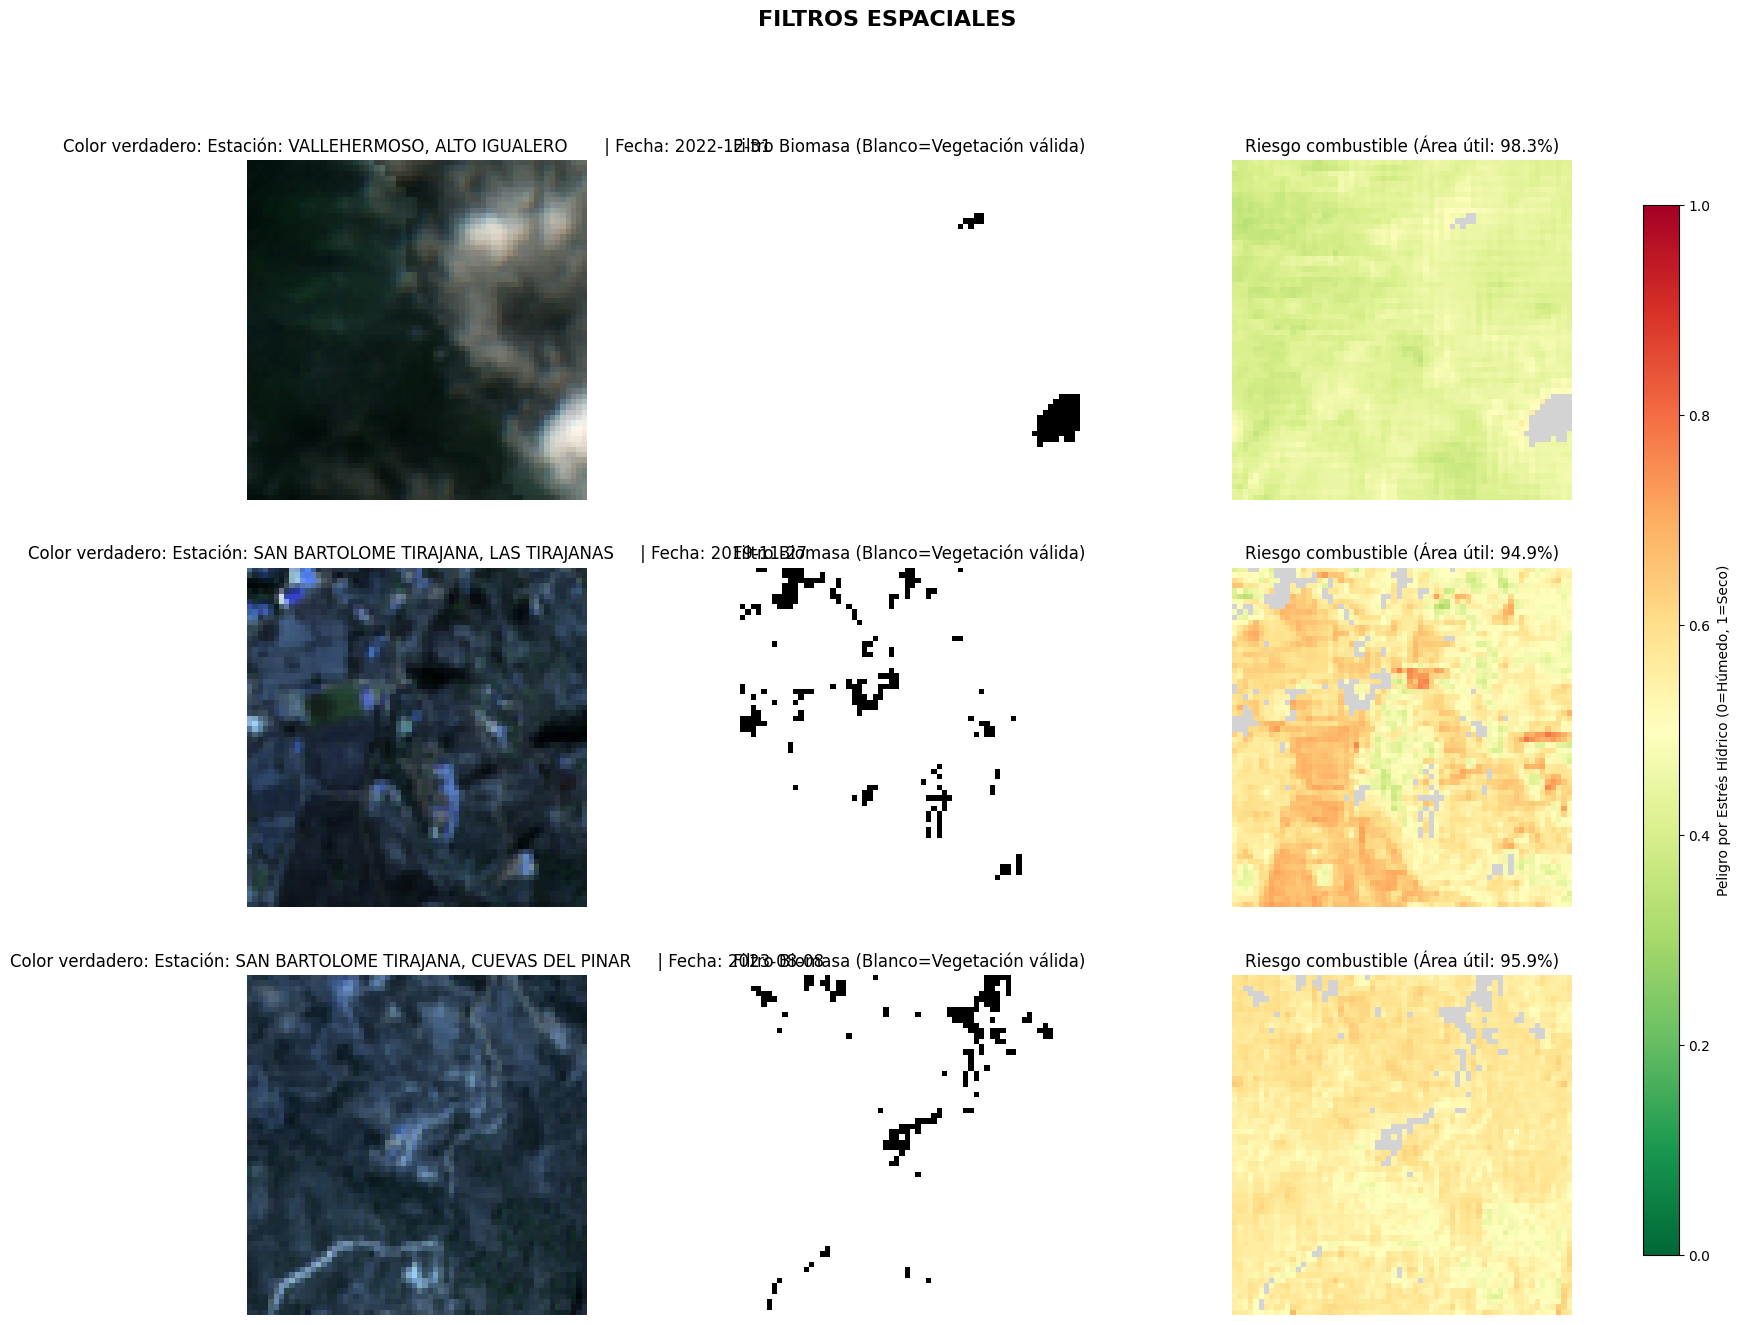

In [5]:
print("Renderizando muestreo aleatorio para comprobar los filtros...")

muestras_azar = df_sincronizado.sample(n=3, random_state=None)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, (index, fila) in enumerate(muestras_azar.iterrows()):
    tensor = np.load(os.path.join(RUTA_TENSORES, fila['nombre_tensor']))

    # Composición RGB Normalizada
    rgb = tensor[:, :, :3]
    rgb_norm = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb) + 1e-8)

    # Análisis Espectral (Triple Filtro)
    b3_green, b4_red, b8_nir, b11_swir = tensor[:, :, 1], tensor[:, :, 2], tensor[:, :, 3], tensor[:, :, 4]

    ndwi = (b3_green - b8_nir) / (b3_green + b8_nir + 1e-8)
    ndvi = (b8_nir - b4_red) / (b8_nir + b4_red + 1e-8)
    mascara_valida = (ndwi <= 0.3) & (ndvi > 0.1)

    # Mapa térmico de riesgo (NDMI)
    ndmi = (b8_nir - b11_swir) / (b8_nir + b11_swir + 1e-8)
    riesgo_matriz = np.clip((1 - ndmi) / 2, 0, 1)
    riesgo_matriz[~mascara_valida] = np.nan

    # Renderizado Izq.: Óptico
    axes[i, 0].imshow(rgb_norm)
    axes[i, 0].set_title(f"Color verdadero: Estación: {fila['nombre']} \
    | Fecha: {fila['fecha']}", fontsize=12)
    axes[i, 0].axis('off')

    # Renderizado Ctral: Máscara Binaria
    axes[i, 1].imshow(mascara_valida, cmap='gray')
    axes[i, 1].set_title("Filtro Biomasa (Blanco=Vegetación válida)", fontsize=12)
    axes[i, 1].axis('off')

    # Renderizado Dcho.: Riesgo de Combustible
    cmap_riesgo = plt.cm.RdYlGn_r
    cmap_riesgo.set_bad('lightgray', 1.)
    im = axes[i, 2].imshow(riesgo_matriz, cmap=cmap_riesgo, vmin=0, vmax=1)
    axes[i, 2].set_title(f"Riesgo combustible (Área útil: {np.mean(mascara_valida)*100:.1f}%)", fontsize=12)
    axes[i, 2].axis('off')

# Configuración y leyenda global
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Peligro por Estrés Hídrico (0=Húmedo, 1=Seco)")
plt.suptitle("FILTROS ESPACIALES", fontsize=16, fontweight='bold')
plt.show()

Comprimimos los archivos generados para su posterior utilizacion, sin tener que volver a ejecutar el Cuaderno 2.

In [ ]:
os.chdir('/content/dataset_tfm')
print("Empaquetando el dataset limpio y los tensores (esto puede tardar unos minutos)...")
!zip -rq datos_entrenamiento_tfm.zip dataset_final_tfm.csv tensores_satelite/

print("\n¡Proceso finalizado con éxito!")
print("Archivos generados en la memoria temporal:")
print("- /content/dataset_tfm/datos_entrenamiento_tfm.zip")
print("- /content/dataset_tfm/robust_scaler_meteo.pkl")

# --- NOTA PARA EL TRIBUNAL EVALUADOR ---
# Los archivos se han generado en la memoria temporal de Colab para evitar errores de permisos.
# Durante la fase de desarrollo, el autor utilizó las siguientes líneas (ahora comentadas) 
# para enviar los resultados a su Google Drive personal y alimentar el Cuaderno 3:
#
# from google.colab import drive
# drive.mount('/content/drive')
# ruta_drive = '/content/drive/MyDrive/TFM_Riesgo_Incendios_Canarias/datos_entrenamiento_tfm.zip'
# ruta_drive_pkl = '/content/drive/MyDrive/TFM_Riesgo_Incendios_Canarias/robust_scaler_meteo.pkl'
# os.makedirs(os.path.dirname(ruta_drive), exist_ok=True)
# shutil.copy('datos_entrenamiento_tfm.zip', ruta_drive)
# shutil.copy('robust_scaler_meteo.pkl', ruta_drive_pkl)


'/content/drive/MyDrive/TFM_Riesgo_Incendios_Canarias/robust_scaler_meteo.pkl'